## Task 1 Data Inspection

1. Find No of col and rows
2. Find data type of each column
3. Extract List of columns names
4. Find number of empty columns
5. Calculate memory usage of each  datashets
6. Find duplicate rows
7. Remove duplicates
8. List of number of unique values in each columns
9. Find no of teams,cities, venues and season
10. Create metadata report of matches

In [2]:
import pandas as pd

matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')


In [15]:
for df_name,  df in {
    'matches': matches,
    'deliveries': deliveries
}.items():
    print(f"DataFrame: {df_name}")
    print(f"Shape: {df.shape}")
    print(f"No of rows: {df.shape[0]}")
    print(f"No of columns: {df.shape[1]}")
    print(f"Columns: {df.columns.tolist()}")
    # print(f"Data types:\n{df.dtypes}")
    print(f"memory usage: {df.memory_usage().sum() / 1024 ** 2:.2f} MB")
    # print(f"Missing values: \n {df.isnull().sum()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
   
    print("---------------------------------")

DataFrame: matches
Shape: (636, 18)
No of rows: 636
No of columns: 18
Columns: ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']
memory usage: 0.09 MB
Duplicate rows: 0
---------------------------------
DataFrame: deliveries
Shape: (150460, 21)
No of rows: 150460
No of columns: 21
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']
memory usage: 24.11 MB
Duplicate rows: 1
---------------------------------


In [22]:
#unique

print(f"Unique values in matches DataFrame: {matches.nunique()}")
print(f"Unique Total Teams: {matches["team1"].nunique()}")
print(f"list of teams: \n {matches["team1"].unique().tolist()}")
print(f"Unique Total Cities: {matches["city"].nunique()}")
print(f"list of cities: \n {matches["city"].unique().tolist()}")
print(f"Unique Total Venues: {matches["venue"].nunique()}")
print(f"list of venues: \n {matches["venue"].unique().tolist()}")

Unique values in matches DataFrame: id                 636
season              10
city                30
date               450
team1               14
team2               14
toss_winner         14
toss_decision        2
result               3
dl_applied           2
winner              14
win_by_runs         86
win_by_wickets      11
player_of_match    201
venue               35
umpire1             44
umpire2             45
umpire3              0
dtype: int64
Unique Total Teams: 14
list of teams: 
 ['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab', 'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers', 'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants']
Unique Total Cities: 30
list of cities: 
 ['Hyderabad', 'Pune', 'Rajkot', 'Indore', 'Bangalore', 'Mumbai', 'Kolkata', 'Delhi', 'Chandigarh', 'Kanpur', 'Jaipur', 'Chennai', 'Cape Town', 'P

In [23]:
#Static high level summary of numeric columns
print(f"Sumary of numeric columns in matches DataFrame:\n{matches.describe()}")

Sumary of numeric columns in matches DataFrame:
               id       season  dl_applied  win_by_runs  win_by_wickets  \
count  636.000000   636.000000  636.000000   636.000000      636.000000   
mean   318.500000  2012.490566    0.025157    13.682390        3.372642   
std    183.741666     2.773026    0.156726    23.908877        3.420338   
min      1.000000  2008.000000    0.000000     0.000000        0.000000   
25%    159.750000  2010.000000    0.000000     0.000000        0.000000   
50%    318.500000  2012.000000    0.000000     0.000000        4.000000   
75%    477.250000  2015.000000    0.000000    20.000000        7.000000   
max    636.000000  2017.000000    1.000000   146.000000       10.000000   

       umpire3  
count      0.0  
mean       NaN  
std        NaN  
min        NaN  
25%        NaN  
50%        NaN  
75%        NaN  
max        NaN  


In [29]:
for df_name, df in [('matches', matches), ('deliveries', deliveries)]:
    print(f"datset: {df_name}")
    
    report = pd.DataFrame(
        columns= ["dataset name", "no of rows", "no of columns", "columns names", "data types", "memory usage", "missing values", "duplicate rows"],
        data=[[df_name, df.shape[0], df.shape[1], df.columns.tolist(), df.dtypes,  df.memory_usage(), df.isnull().sum(), df.duplicated().sum()]] 
    )
    print(report)

datset: matches
  dataset name  no of rows  no of columns  \
0      matches         636             18   

                                       columns names  \
0  [id, season, city, date, team1, team2, toss_wi...   

                                          data types  \
0  id                   int64
season             ...   

                                        memory usage  \
0  Index               132
id                 508...   

                                      missing values  duplicate rows  
0  id                   0
season               0
...               0  
datset: deliveries
  dataset name  no of rows  no of columns  \
0   deliveries      150460             21   

                                       columns names  \
0  [match_id, inning, batting_team, bowling_team,...   

                                          data types  \
0  match_id            int64
inning              ...   

                                        memory usage  \
0  Index            

## Task 2 Filteration

1. Filter matches played by each time
2. Matches played by team1 and team 2
3. No Of macthes won by team
4. Win percentage
5. List no of top 5 teams  with max win %
6. List matches who won toss and bat first
7. List matches played in given city

 No of matches played by Mumbai Indians: 157
Win percentage of Mumbai Indians: 58.60%
 No of matches played between Mumbai Indians and Chennai Super Kings: 22


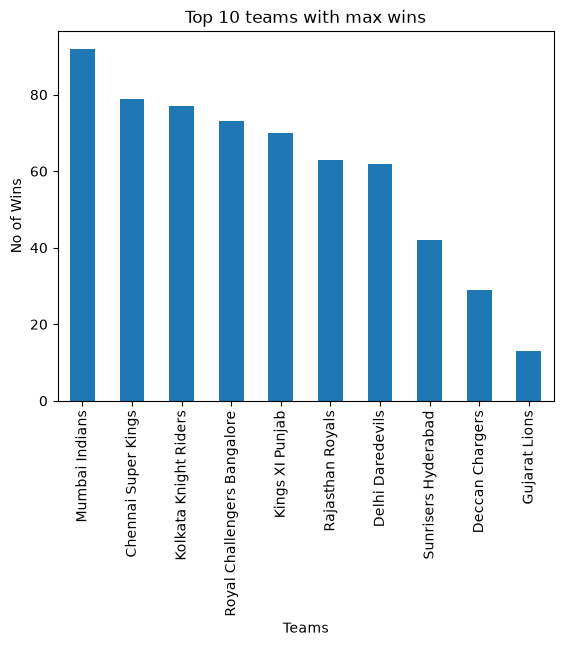

In [47]:
def match_played_by_team(team):
    mask1 = (matches["team1"] == team) | (matches["team2"] == team)
    print(f" No of matches played by {team}: {matches[mask1].shape[0]}" )


def matches_played_by_teams(team1, team2):
    mask = ((matches["team1"] == team1) & (matches["team2"] == team2)) | ((matches["team1"] == team2) & (matches["team2"] == team1))
    print(f" No of matches played between {team1} and {team2}: {matches[mask].shape[0]}" )


def top_n_winner_teams(n):
    sorted_winners = matches["winner"].value_counts().sort_values(ascending=False).head(n)
    sorted_winners.plot(kind="bar", title=f"Top {n} teams with max wins", xlabel="Teams", ylabel="No of Wins")
    
    
def calculate_win_percentage(team):
    win_mask = matches["winner"] == team
    total_win_matches = matches[win_mask].shape[0]
    
    total_match_mask = (matches["team1"] == team) | (matches["team2"] == team)
    total_matches = matches[total_match_mask].shape[0]
    
    win_percentage = (total_win_matches / total_matches) * 100
    
    print(f"Win percentage of {team}: {win_percentage:.2f}%")
    
    
def team_calculation(team):
    match_played_by_team(team)
    calculate_win_percentage(team)
    top_n_winner_teams(10)
    matches_played_by_teams("Mumbai Indians", "Chennai Super Kings")
    
team_calculation("Mumbai Indians")

- Task 1. Find all matches where "Chennai Super Kings" won the toss AND decided to bat first.

In [52]:
def filter_match_won_toss_sel_bat(team):
    mask = (matches["toss_winner"] == team) & (matches["toss_decision"] == "bat")
    return matches[mask].shape[0]

filter_match_won_toss_sel_bat("Chennai Super Kings")

44

In [54]:
def matches_played_in_cities(cities):
   mask = matches["city"].isin(cities)
   return matches[mask]

matches_played_in_cities(["Bangalore"])

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
11,12,2017,Bangalore,2017-04-14,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN
16,17,2017,Bangalore,2017-04-16,Rising Pune Supergiant,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Rising Pune Supergiant,27,0,BA Stokes,M Chinnaswamy Stadium,KN Ananthapadmanabhan,C Shamshuddin,NaN
29,30,2017,Bangalore,2017-04-27,Royal Challengers Bangalore,Gujarat Lions,Gujarat Lions,field,normal,0,Gujarat Lions,0,7,AJ Tye,M Chinnaswamy Stadium,AK Chaudhary,C Shamshuddin,NaN
41,42,2017,Bangalore,2017-05-05,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kings XI Punjab,19,0,Sandeep Sharma,M Chinnaswamy Stadium,CB Gaffaney,C Shamshuddin,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,617,2016,Bangalore,2016-05-11,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,6,KH Pandya,M Chinnaswamy Stadium,AY Dandekar,C Shamshuddin,NaN
619,620,2016,Bangalore,2016-05-14,Royal Challengers Bangalore,Gujarat Lions,Gujarat Lions,field,normal,0,Royal Challengers Bangalore,144,0,AB de Villiers,M Chinnaswamy Stadium,AY Dandekar,VK Sharma,NaN
625,626,2016,Bangalore,2016-05-18,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,1,Royal Challengers Bangalore,82,0,V Kohli,M Chinnaswamy Stadium,KN Ananthapadmanabhan,M Erasmus,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN


In [64]:
# Matches that ended in a tie or had no result
matches[(matches["result"] == "tie") | (matches["result"] == "no result")]

#Matches have missing value

    

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
33,34,2017,Rajkot,2017-04-29,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,tie,0,Mumbai Indians,0,0,KH Pandya,Saurashtra Cricket Association Stadium,AK Chaudhary,CB Gaffaney,NaN
125,126,2009,Cape Town,2009-04-23,Rajasthan Royals,Kolkata Knight Riders,Kolkata Knight Riders,field,tie,0,Rajasthan Royals,0,0,YK Pathan,Newlands,MR Benson,M Erasmus,NaN
189,190,2010,Chennai,2010-03-21,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,field,tie,0,Kings XI Punjab,0,0,J Theron,"MA Chidambaram Stadium, Chepauk",K Hariharan,DJ Harper,NaN
300,301,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker,NaN
387,388,2013,Hyderabad,2013-04-07,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,bat,tie,0,Sunrisers Hyderabad,0,0,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",AK Chaudhary,S Ravi,NaN
400,401,2013,Bangalore,2013-04-16,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,tie,0,Royal Challengers Bangalore,0,0,V Kohli,M Chinnaswamy Stadium,M Erasmus,VA Kulkarni,NaN
475,476,2014,Abu Dhabi,2014-04-29,Rajasthan Royals,Kolkata Knight Riders,Rajasthan Royals,bat,tie,0,Rajasthan Royals,0,0,JP Faulkner,Sheikh Zayed Stadium,Aleem Dar,AK Chaudhary,NaN
535,536,2015,Ahmedabad,2015-04-21,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,tie,0,Kings XI Punjab,0,0,SE Marsh,"Sardar Patel Stadium, Motera",M Erasmus,S Ravi,NaN
545,546,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak,NaN
570,571,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan,NaN


In [61]:
# Deliveries Batsman Hit 6
def deliveries_batsman_hit_6():
    mask = deliveries["total_runs"] == 6
    total_6 = deliveries[mask].shape[0]
    print(f"Total number of deliveries where batsman hit 6: {total_6}")

# Deliveries Batsman Hit Boundary
def balls_scored_boundary():
    total_boundary = deliveries[deliveries["total_runs"].isin([4, 6])].shape[0]
    print(f"Total number of deliveries where batsman hit boundary (4 or 6): {total_boundary}")

# Deliveries Batsman Hit Dot Ball
def find_total_dot_balls():
    total_dot_balls = deliveries[deliveries["total_runs"] == 0].shape[0]
    print(f"Total number of dot balls: {total_dot_balls}")
    
# Deliveries Batsman Got Dismissed
def deliveries_batsman_got_dismissed():
    return deliveries[deliveries["dismissal_kind"].notnull()]

# Plot Bar Chart for Dismissal Kind
def plot_bar_chart_dismissal_kind():
    dismissial_count = deliveries["dismissal_kind"].value_counts()
    dismissial_count.plot(kind="bar", title="Dismissal Kind Count", xlabel="Dismissal Kind", ylabel="Count")

# Filter Deliveries for a Specific Player Dismissed
def filter_player_dismissed(player_name):
    dismissal_mask = deliveries["player_dismissed"] == player_name
    
    # plot graph for the player dismissed
    player_dismissal_count = deliveries[deliveries["player_dismissed"] == player_name]["dismissal_kind"].value_counts()
    player_dismissal_count.plot(kind="bar", title=f"{player_name} Dismissal type", xlabel="Dismissal Kind", ylabel="Count")
    # deliveries[dismissal_mask].value_counts().plot(kind="bar", title=f"{player_name} Dismissal Count by {dismissal_kind}", xlabel="Dismissal Kind", ylabel="Count")
    return deliveries[dismissal_mask]

# Count Matches Played Between Two Seasons
def matches_played_between_season(year1, year2):
    mask = (matches["season"] >= year1) & (matches["season"] <= year2)
    return matches[mask].shape[0]

# Count Matches Won by Largest Margin
def matches_won_by_largest_margin(run):
    mask = matches["win_by_runs"] >= run
    return matches[mask].shape[0]

# filter deliveries for a specific batting team in death overs (16-20) with runs >= 4 and no wickets
def interview_fav(batting_team):
    batting_team_mask = deliveries["batting_team"] == batting_team
    over_mask = deliveries["over"].between(16, 20)
    run_mask = deliveries["total_runs"] >= 4
    wicket_mask = deliveries["player_dismissed"].isnull()
    filtered_deliveries = deliveries[batting_team_mask & over_mask & run_mask & wicket_mask]
    return filtered_deliveries

interview_fav("Chennai Super Kings")

#count death over deliveries
print(deliveries[(deliveries["over"] >=16) & (deliveries["over"] <=20)].shape[0])
print(deliveries[(deliveries["over"].isin([16, 17, 18, 19, 20]))].shape[0])
print(deliveries[deliveries["over"].between(16, 20)].shape[0])

#find powerplay deliveries
print(deliveries[deliveries["over"].between(1, 6)].shape[0])

# Find percentage of missing values in matches DataFrame
print(matches.isnull().mean().multiply(100).round(2))

# Fill missing values in the "city" column with "Unknown"
matches["city"] = matches["city"].fillna("Unknown")
print(matches[matches["city"] == "Unknown"].shape[0])

# Find matches with missing winner values
print(matches[matches["winner"].isnull()])

#drop rows with missing winner values
matches = matches.dropna(subset=["winner"])








33737
33737
33737
47683
id                   0.00
season               0.00
city                 0.00
date                 0.00
team1                0.00
team2                0.00
toss_winner          0.00
toss_decision        0.00
result               0.00
dl_applied           0.00
winner               0.00
win_by_runs          0.00
win_by_wickets       0.00
player_of_match      0.00
venue                0.00
umpire1              0.16
umpire2              0.16
umpire3            100.00
dtype: float64
7
Empty DataFrame
Columns: [id, season, city, date, team1, team2, toss_winner, toss_decision, result, dl_applied, winner, win_by_runs, win_by_wickets, player_of_match, venue, umpire1, umpire2, umpire3]
Index: []
